# Deepfake Detection Model: Generalization to Everyday Objects (CIFAKE)

This notebook evaluates whether an EfficientNetB4 model trained on real vs. AI-generated **human faces** generalizes to classifying real vs. AI-generated **everyday objects**.

**Research question:** Do the visual artifacts learned from face-based deepfake detection transfer to AI-generated object images?

**Dataset:** [CIFAKE](https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images) — 120K images (60K real from CIFAR-10 + 60K AI-generated via Stable Diffusion). 10 categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

**Model:** `redeepfake_model.h5` — EfficientNetB4 trained on face deepfake detection (89.4% accuracy on faces)

**Pipeline (mirrors Maxwell's art evaluation):**
1. Load & explore CIFAKE dataset
2. Exploratory data analysis
3. Zero-shot evaluation — apply face model directly, no retraining
4. Fine-tune — freeze EfficientNetB4 backbone, train new head on CIFAKE
5. Three-way comparison: Faces / Art (Maxwell) / Objects (Axel)

## 1. Imports & Configuration

In [1]:
import os, warnings, random
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)

MODEL_PATH = Path('/Users/axelndombasi/CS663/Final Project/redeepfake_model.h5')
BATCH_SIZE = 32
MAX_IMAGES = 2000  # per class — 2K×2 = 4K total ≈ 2.4 GB RAM (safe on 18 GB)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.21.0
GPU        : []


## 2. Load CIFAKE Dataset

In [2]:
import kagglehub
dataset_path = kagglehub.dataset_download('birdy654/cifake-real-and-ai-generated-synthetic-images')
CIFAKE_ROOT = Path(dataset_path)
print(f'CIFAKE path: {CIFAKE_ROOT}')

# Build dataframe of all image paths + labels + class names
records = []
for split in ['train', 'test']:
    split_dir = CIFAKE_ROOT / split
    if not split_dir.exists():
        split_dir = CIFAKE_ROOT / split.upper()
    for cls_dir in split_dir.iterdir():
        if not cls_dir.is_dir():
            continue
        cls_name = cls_dir.name  # 'REAL' or 'FAKE'
        label = 0 if cls_name.upper() == 'REAL' else 1
        for img_path in cls_dir.glob('*.jpg'):
            records.append({'path': str(img_path), 'label': label,
                            'class_name': cls_name.upper(), 'split': split})

full_df = pd.DataFrame(records)
print(f'Total images found: {len(full_df):,}')
print(full_df['class_name'].value_counts().to_string())

CIFAKE path: /Users/axelndombasi/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3
Total images found: 120,000
class_name
REAL    60000
FAKE    60000


In [3]:
# Sample up to MAX_IMAGES per class for working subset
df = pd.concat([
    full_df[full_df['label'] == lbl].sample(
        min((full_df['label'] == lbl).sum(), MAX_IMAGES),
        random_state=SEED
    )
    for lbl in full_df['label'].unique()
]).reset_index(drop=True)

print(f'Working dataset: {len(df):,} images')
print(df['class_name'].value_counts().to_string())

Working dataset: 4,000 images
class_name
REAL    2000
FAKE    2000


## 3. Exploratory Data Analysis

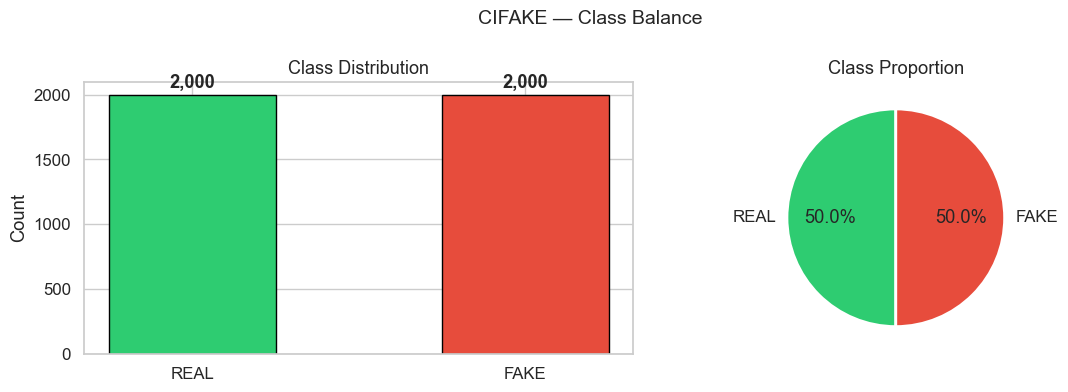

In [4]:
# Class distribution
counts = df['class_name'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 50, f'{cnt:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')
plt.suptitle('CIFAKE — Class Balance', fontsize=14)
plt.tight_layout()
plt.show()

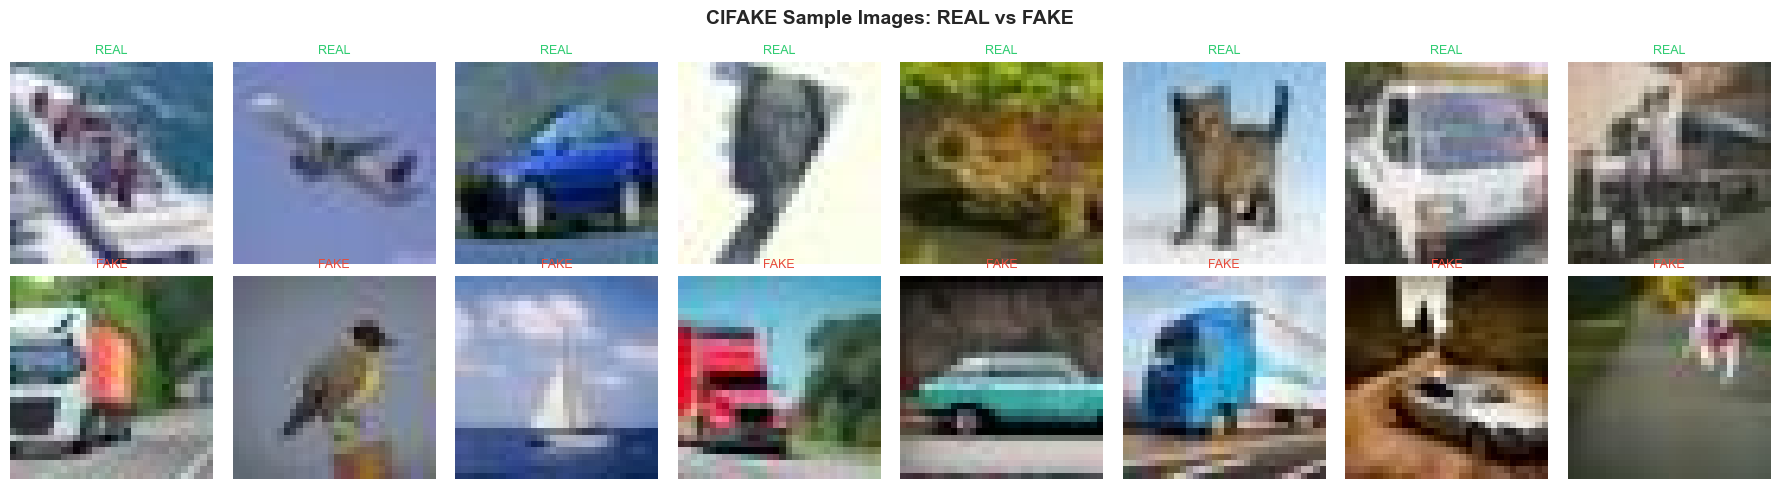

In [5]:
# Sample images: REAL vs FAKE side by side
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('CIFAKE Sample Images: REAL vs FAKE', fontsize=14, fontweight='bold')

for col, row in enumerate(df[df['label'] == 0].sample(8, random_state=SEED).itertuples()):
    axes[0, col].imshow(Image.open(row.path))
    axes[0, col].set_title('REAL', color='#2ecc71', fontsize=9)
    axes[0, col].axis('off')

for col, row in enumerate(df[df['label'] == 1].sample(8, random_state=SEED).itertuples()):
    axes[1, col].imshow(Image.open(row.path))
    axes[1, col].set_title('FAKE', color='#e74c3c', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Image metadata: resolution check
widths, heights, labels_meta = [], [], []
for _, row in df.sample(min(500, len(df)), random_state=SEED).iterrows():
    try:
        w, h = Image.open(row['path']).size
        widths.append(w); heights.append(h); labels_meta.append(row['label'])
    except Exception:
        pass

print(f'Width  — mean: {np.mean(widths):.1f}, std: {np.std(widths):.1f}, range: {min(widths)}–{max(widths)}')
print(f'Height — mean: {np.mean(heights):.1f}, std: {np.std(heights):.1f}, range: {min(heights)}–{max(heights)}')
print(f'\nAll images are 32×32 pixels. Model input requires {224}×{224} — will upsample.')

Width  — mean: 32.0, std: 0.0, range: 32–32
Height — mean: 32.0, std: 0.0, range: 32–32

All images are 32×32 pixels. Model input requires 224×224 — will upsample.


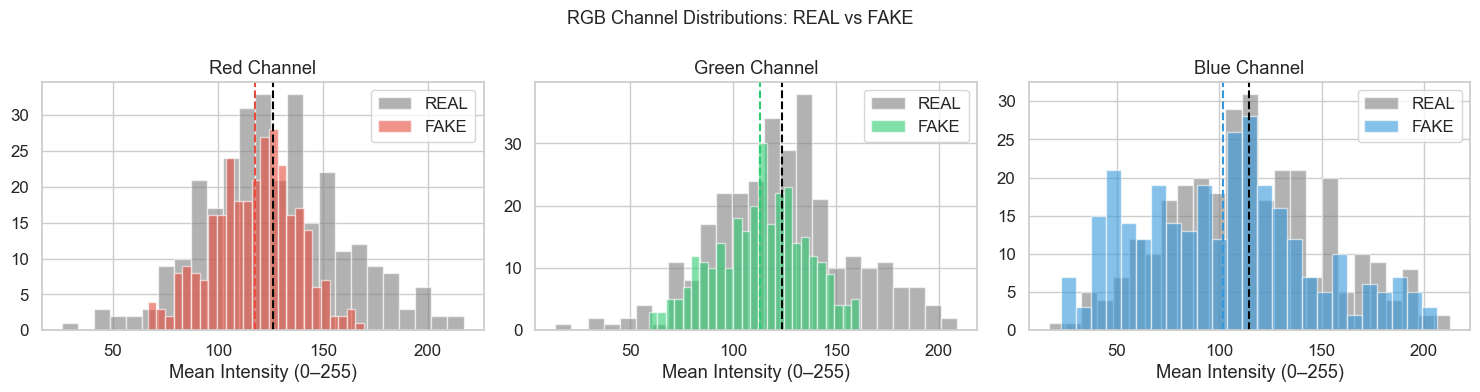

Channel     REAL mean    FAKE mean       Diff
---------------------------------------------
Red            126.22       117.45      -8.76
Green          123.60       113.32     -10.28
Blue           114.50       101.58     -12.92


In [7]:
# RGB channel distribution: REAL vs FAKE
N_SAMPLE = 300
channel_stats = {cls: {'r': [], 'g': [], 'b': []} for cls in ['REAL', 'FAKE']}

for cls in ['REAL', 'FAKE']:
    lbl = 0 if cls == 'REAL' else 1
    paths = df[df['label'] == lbl].sample(N_SAMPLE, random_state=SEED)['path']
    for path in paths:
        try:
            arr = np.array(Image.open(path).convert('RGB'), dtype=np.float32)
            channel_stats[cls]['r'].append(arr[:,:,0].mean())
            channel_stats[cls]['g'].append(arr[:,:,1].mean())
            channel_stats[cls]['b'].append(arr[:,:,2].mean())
        except Exception:
            pass

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ch_display = [('Red','r','#e74c3c'), ('Green','g','#2ecc71'), ('Blue','b','#3498db')]

for ax, (ch_name, ch_key, ch_color) in zip(axes, ch_display):
    ax.hist(channel_stats['REAL'][ch_key], bins=25, alpha=0.6, label='REAL', color='gray')
    ax.hist(channel_stats['FAKE'][ch_key], bins=25, alpha=0.6, label='FAKE', color=ch_color)
    ax.axvline(np.mean(channel_stats['REAL'][ch_key]), color='black',  linestyle='--', lw=1.5)
    ax.axvline(np.mean(channel_stats['FAKE'][ch_key]), color=ch_color, linestyle='--', lw=1.5)
    ax.set_title(f'{ch_name} Channel')
    ax.set_xlabel('Mean Intensity (0–255)')
    ax.legend()

plt.suptitle('RGB Channel Distributions: REAL vs FAKE', fontsize=13)
plt.tight_layout()
plt.show()

print(f'{"Channel":<8} {"REAL mean":>12} {"FAKE mean":>12} {"Diff":>10}')
print('-' * 45)
for ch_name, ch_key, _ in ch_display:
    rm = np.mean(channel_stats['REAL'][ch_key])
    fm = np.mean(channel_stats['FAKE'][ch_key])
    print(f'{ch_name:<8} {rm:>12.2f} {fm:>12.2f} {fm-rm:>+10.2f}')

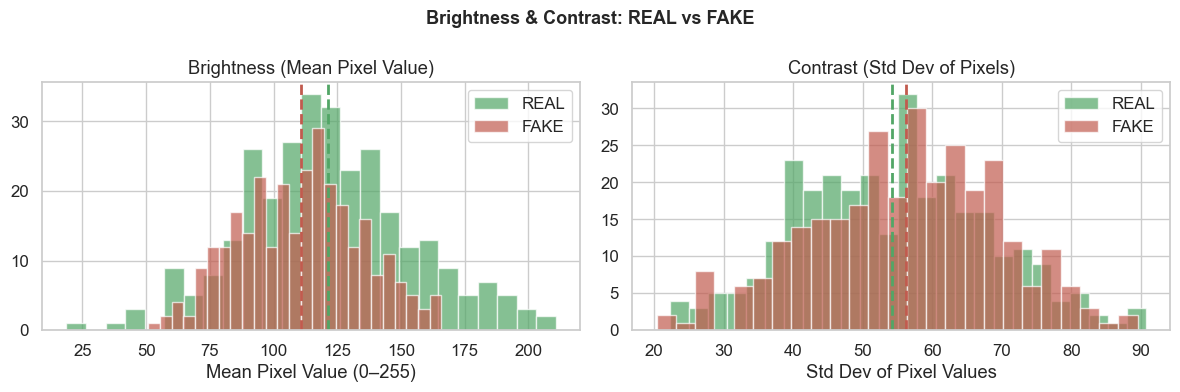

Brightness — REAL: 121.44 ± 32.73  |  FAKE: 110.78 ± 23.90
Contrast   — REAL: 54.17   ± 13.73  |  FAKE: 56.26   ± 13.28


In [8]:
# Brightness and contrast analysis
real_brightness, fake_brightness = [], []
real_contrast,   fake_contrast   = [], []

for cls, b_list, c_list in [('REAL', real_brightness, real_contrast), ('FAKE', fake_brightness, fake_contrast)]:
    lbl = 0 if cls == 'REAL' else 1
    paths = df[df['label'] == lbl].sample(N_SAMPLE, random_state=SEED)['path']
    for path in paths:
        try:
            arr = np.array(Image.open(path).convert('RGB'), dtype=np.float32)
            b_list.append(arr.mean())
            c_list.append(arr.std())
        except Exception:
            pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Brightness & Contrast: REAL vs FAKE', fontsize=13, fontweight='bold')

for ax, (r_data, f_data), title, xlabel in zip(
    axes,
    [(real_brightness, fake_brightness), (real_contrast, fake_contrast)],
    ['Brightness (Mean Pixel Value)', 'Contrast (Std Dev of Pixels)'],
    ['Mean Pixel Value (0–255)', 'Std Dev of Pixel Values']
):
    ax.hist(r_data, bins=25, alpha=0.7, color='#52A666', label='REAL')
    ax.hist(f_data, bins=25, alpha=0.7, color='#C15B4E', label='FAKE')
    ax.axvline(np.mean(r_data), color='#52A666', linestyle='--', lw=2)
    ax.axvline(np.mean(f_data), color='#C15B4E', linestyle='--', lw=2)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.legend()

plt.tight_layout()
plt.show()

print(f'Brightness — REAL: {np.mean(real_brightness):.2f} ± {np.std(real_brightness):.2f}  |  FAKE: {np.mean(fake_brightness):.2f} ± {np.std(fake_brightness):.2f}')
print(f'Contrast   — REAL: {np.mean(real_contrast):.2f}   ± {np.std(real_contrast):.2f}  |  FAKE: {np.mean(fake_contrast):.2f}   ± {np.std(fake_contrast):.2f}')

## 4. Load Pretrained Model

In [9]:
import tf_keras
from tf_keras.layers import DepthwiseConv2D as _DWConv2D

# TF 2.16+ uses Keras 3 which rejects the 'groups' kwarg that TF 2.13 saved.
# tf_keras is the legacy Keras 2 compatibility layer — load through it instead.
class DepthwiseConv2D(_DWConv2D):
    def __init__(self, *args, **kwargs):
        kwargs.pop('groups', None)
        super().__init__(*args, **kwargs)

print(f'Loading model from {MODEL_PATH}...')
model = tf_keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={'DepthwiseConv2D': DepthwiseConv2D},
    compile=False
)
print(f'Model loaded!')
print(f'Input : {model.input_shape}')
print(f'Output: {model.output_shape}')
TARGET_SIZE = model.input_shape[1]

print('\nLayers:')
for layer in model.layers:
    print(f'  {layer.name:45s} {layer.__class__.__name__}')

# Quick sanity check: are weights valid?
import h5py
nan_count = 0
with h5py.File(str(MODEL_PATH), 'r') as f:
    def _check(name, obj):
        global nan_count
        if isinstance(obj, h5py.Dataset) and 'kernel' in name:
            if np.any(np.isnan(obj[()])):
                nan_count += 1
    f.visititems(_check)
if nan_count > 0:
    print(f'\n⚠️  WARNING: {nan_count} weight tensors contain NaN — model is corrupt!')
else:
    print('\n✅ Weight sanity check: no NaN values found.')

Loading model from /Users/axelndombasi/CS663/Final Project/redeepfake_model.h5...
Model loaded!
Input : (None, 224, 224, 3)
Output: (None, 1)

Layers:
  input_2                                       InputLayer
  sequential                                    Sequential
  efficientnetb4                                Functional
  global_average_pooling2d                      GlobalAveragePooling2D
  dense                                         Dense

✅ Weight sanity check: no NaN values found.


## 5. Preprocessing
CIFAKE images are 32×32 — we upsample to the model's native 224×224 using bilinear interpolation.

In [10]:
def load_and_preprocess(path, size):
    img = Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR)
    return preprocess_input(np.array(img, dtype=np.float32))

print(f'Preprocessing {len(df):,} images at {TARGET_SIZE}×{TARGET_SIZE}...')
X_list, y_list = [], []

for _, row in df.iterrows():
    try:
        X_list.append(load_and_preprocess(row['path'], TARGET_SIZE))
        y_list.append(row['label'])
    except Exception:
        pass

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f'X shape : {X.shape}')
print(f'REAL: {(y==0).sum():,}  |  FAKE: {(y==1).sum():,}')

Preprocessing 4,000 images at 224×224...
X shape : (4000, 224, 224, 3)
REAL: 2,000  |  FAKE: 2,000


## 6. Zero-Shot Evaluation
Apply the face-trained model directly to CIFAKE — no retraining whatsoever.

In [11]:
print('Running zero-shot inference...')
probs = model.predict(X, batch_size=BATCH_SIZE, verbose=1).flatten()
preds = (probs >= 0.5).astype(int)

zs_acc  = accuracy_score(y, preds)
zs_auc  = roc_auc_score(y, probs)
zs_prec = precision_score(y, preds, zero_division=0)
zs_rec  = recall_score(y, preds, zero_division=0)
zs_f1   = f1_score(y, preds, zero_division=0)
baseline_acc = max((y==0).mean(), (y==1).mean())

print('='*52)
print('  ZERO-SHOT RESULTS (face model → objects)')
print('='*52)
print(f'  Majority baseline : {baseline_acc:.4f}')
print(f'  Accuracy          : {zs_acc:.4f} ({zs_acc*100:.2f}%)')
print(f'  ROC-AUC           : {zs_auc:.4f}')
print(f'  Precision (FAKE)  : {zs_prec:.4f}')
print(f'  Recall (FAKE)     : {zs_rec:.4f}')
print(f'  F1 Score          : {zs_f1:.4f}')
print('='*52)
print()
print(classification_report(y, preds, target_names=['REAL', 'FAKE']))

Running zero-shot inference...
125/125 [==============================] - 52s 400ms/step
  ZERO-SHOT RESULTS (face model → objects)
  Majority baseline : 0.5000
  Accuracy          : 0.4963 (49.62%)
  ROC-AUC           : 0.5263
  Precision (FAKE)  : 0.4931
  Recall (FAKE)     : 0.2680
  F1 Score          : 0.3473

              precision    recall  f1-score   support

        REAL       0.50      0.72      0.59      2000
        FAKE       0.49      0.27      0.35      2000

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.47      4000
weighted avg       0.50      0.50      0.47      4000



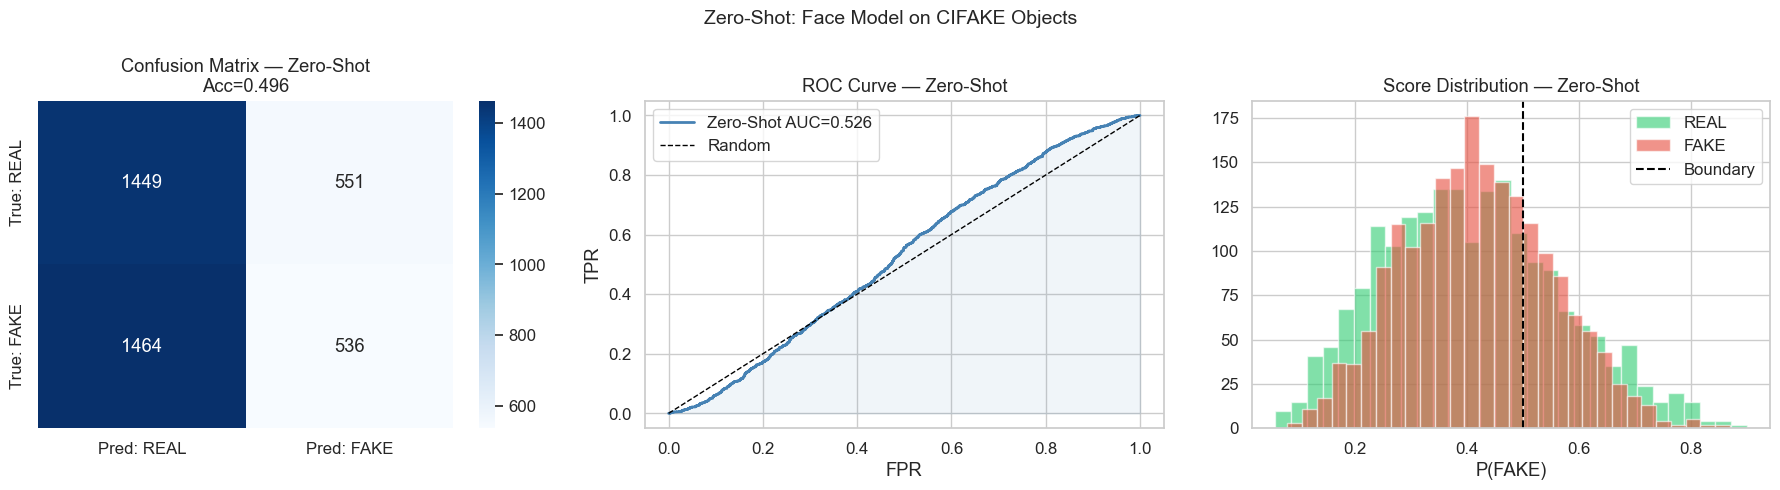

In [12]:
cm  = confusion_matrix(y, preds)
fpr, tpr, _ = roc_curve(y, probs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: REAL','Pred: FAKE'],
            yticklabels=['True: REAL','True: FAKE'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — Zero-Shot\nAcc={zs_acc:.3f}')

axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'Zero-Shot AUC={zs_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Zero-Shot'); axes[1].legend()

for lbl, cls_name, color in [(0,'REAL','#2ecc71'),(1,'FAKE','#e74c3c')]:
    axes[2].hist(probs[y==lbl], bins=30, alpha=0.6, label=cls_name, color=color)
axes[2].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Boundary')
axes[2].set_title('Score Distribution — Zero-Shot')
axes[2].set_xlabel('P(FAKE)'); axes[2].legend()

plt.suptitle('Zero-Shot: Face Model on CIFAKE Objects', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Fine-Tuning
Freeze the EfficientNetB4 backbone. Train a new classification head on CIFAKE images.

In [13]:
# 70 / 15 / 15 stratified split
X_tv, X_test_ft, y_tv, y_test_ft = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train_ft, X_val_ft, y_train_ft, y_val_ft = train_test_split(
    X_tv, y_tv, test_size=0.176, random_state=SEED, stratify=y_tv)

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train_ft)
class_weights = {0: cw[0], 1: cw[1]}

print(f'Train : {len(X_train_ft):,}  Val : {len(X_val_ft):,}  Test : {len(X_test_ft):,}')
print(f'Class weights — REAL: {cw[0]:.3f}  FAKE: {cw[1]:.3f}')

Train : 2,801  Val : 599  Test : 600
Class weights — REAL: 1.000  FAKE: 1.000


In [14]:
# Build fine-tuned model: frozen backbone + new head
backbone = model.get_layer('efficientnetb4')
backbone.trainable = False

augment = tf_keras.Sequential([
    tf_keras.layers.RandomFlip('horizontal'),
    tf_keras.layers.RandomRotation(0.08),
    tf_keras.layers.RandomZoom(0.10),
], name='augmentation')

inp = tf_keras.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3), name='cifake_input')
x   = augment(inp)
x   = backbone(x, training=False)
x   = tf_keras.layers.GlobalAveragePooling2D()(x)
x   = tf_keras.layers.BatchNormalization()(x)
x   = tf_keras.layers.Dropout(0.4)(x)
x   = tf_keras.layers.Dense(256, activation='relu')(x)
x   = tf_keras.layers.Dropout(0.3)(x)
out = tf_keras.layers.Dense(1, activation='sigmoid', name='cifake_output')(x)

ft_model = tf_keras.Model(inp, out, name='efficientnetb4_cifake_finetuned')
ft_model.compile(
    optimizer=tf_keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf_keras.metrics.AUC(name='auc')]
)

trainable = sum(np.prod(w.shape) for w in ft_model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in ft_model.non_trainable_weights)
print(f'Trainable : {trainable:,}  |  Frozen : {frozen:,}  ({frozen/(trainable+frozen)*100:.1f}%)')

Trainable : 462,849  |  Frozen : 17,677,407.0  (97.4%)


In [15]:
callbacks = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=6,
        restore_best_weights=True, verbose=1),
    tf_keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', mode='max', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1),
]

print('Training fine-tuned model...')
history = ft_model.fit(
    X_train_ft, y_train_ft,
    validation_data=(X_val_ft, y_val_ft),
    epochs=25,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Training fine-tuned model...
Epoch 1/25
176/176 [==============================] - 51s 259ms/step - loss: 0.7297 - accuracy: 0.7208 - auc: 0.8049 - val_loss: 0.3678 - val_accuracy: 0.8347 - val_auc: 0.9173 - lr: 0.0010
Epoch 2/25
176/176 [==============================] - 46s 264ms/step - loss: 0.5001 - accuracy: 0.7990 - auc: 0.8861 - val_loss: 0.3195 - val_accuracy: 0.8698 - val_auc: 0.9370 - lr: 0.0010
Epoch 3/25
176/176 [==============================] - 45s 255ms/step - loss: 0.4169 - accuracy: 0.8322 - auc: 0.9095 - val_loss: 0.2916 - val_accuracy: 0.8781 - val_auc: 0.9495 - lr: 0.0010
Epoch 4/25
176/176 [==============================] - 44s 249ms/step - loss: 0.3986 - accuracy: 0.8340 - auc: 0.9136 - val_loss: 0.2972 - val_accuracy: 0.8781 - val_auc: 0.9472 - lr: 0.0010
Epoch 5/25
176/176 [==============================] - 46s 261ms/step - loss: 0.3539 - accuracy: 0.8418 - auc: 0.9252 - val_loss: 0.2911 - val_accuracy: 0.8815 - val_auc: 0.9493 - lr: 0.0010
Epoch 6/25
176/176 [=

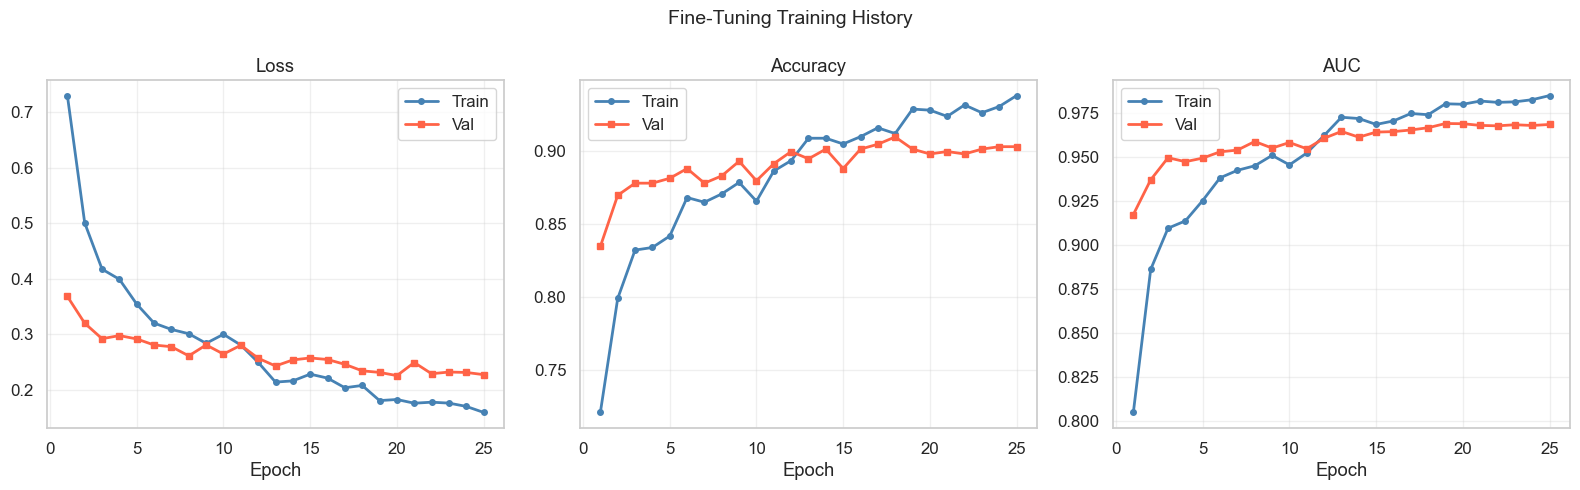

In [16]:
# Training history
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (tr, val), title in zip(axes,
    [('loss','val_loss'),('accuracy','val_accuracy'),('auc','val_auc')],
    ['Loss','Accuracy','AUC']):
    ax.plot(epochs_ran, hist[tr],  'o-', color='steelblue', label='Train', lw=2, ms=4)
    ax.plot(epochs_ran, hist[val], 's-', color='tomato',    label='Val',   lw=2, ms=4)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Fine-Tuning Training History', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Fine-Tuned Model Evaluation

              precision    recall  f1-score   support

        REAL       0.89      0.86      0.88       300
        FAKE       0.87      0.89      0.88       300

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600



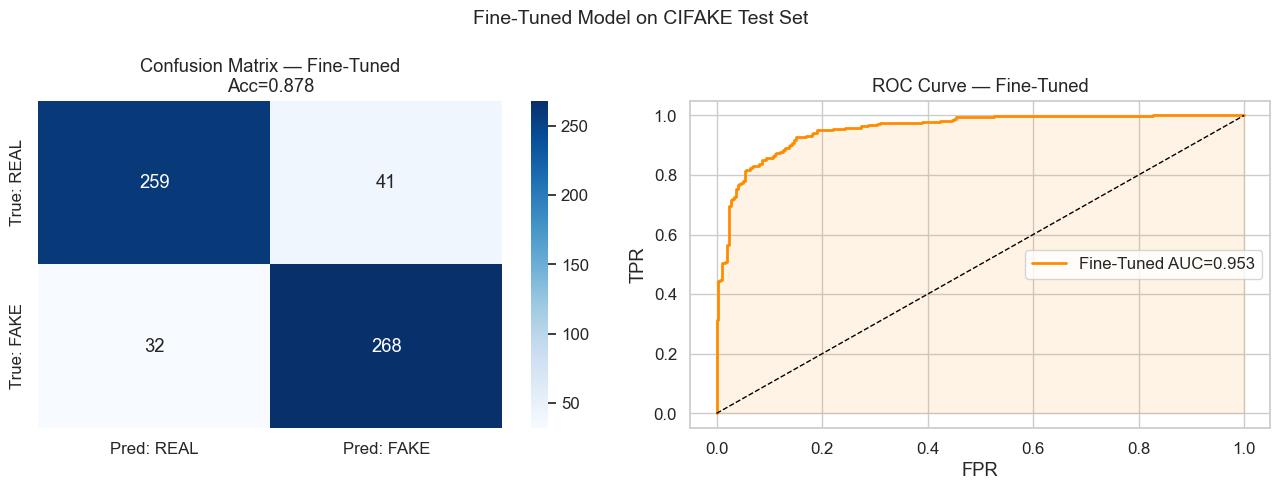

In [17]:
ft_probs = ft_model.predict(X_test_ft, batch_size=16, verbose=0).flatten()
ft_preds = (ft_probs >= 0.5).astype(int)

ft_acc  = accuracy_score(y_test_ft, ft_preds)
ft_auc  = roc_auc_score(y_test_ft, ft_probs)
ft_prec = precision_score(y_test_ft, ft_preds, zero_division=0)
ft_rec  = recall_score(y_test_ft, ft_preds, zero_division=0)
ft_f1   = f1_score(y_test_ft, ft_preds, zero_division=0)

print(classification_report(y_test_ft, ft_preds, target_names=['REAL', 'FAKE']))

ft_cm = confusion_matrix(y_test_ft, ft_preds)
ft_fpr, ft_tpr, _ = roc_curve(y_test_ft, ft_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(ft_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: REAL','Pred: FAKE'],
            yticklabels=['True: REAL','True: FAKE'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — Fine-Tuned\nAcc={ft_acc:.3f}')

axes[1].plot(ft_fpr, ft_tpr, color='darkorange', lw=2, label=f'Fine-Tuned AUC={ft_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].fill_between(ft_fpr, ft_tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Fine-Tuned'); axes[1].legend()

plt.suptitle('Fine-Tuned Model on CIFAKE Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Three-Way Comparison
Faces (baseline) → Art (Maxwell) → Everyday Objects (Axel)

  Model                                    Accuracy    ROC-AUC
  Face model on Faces (training domain)      0.8936      ~0.95
  Face model → Art     (Maxwell, zero-shot)     0.4419     0.4568
  Face model → Objects (ours,   zero-shot)     0.4963     0.5263
  Fine-tuned → Art     (Maxwell)                  –     0.6965
  Fine-tuned → Objects (ours)                0.8783     0.9534


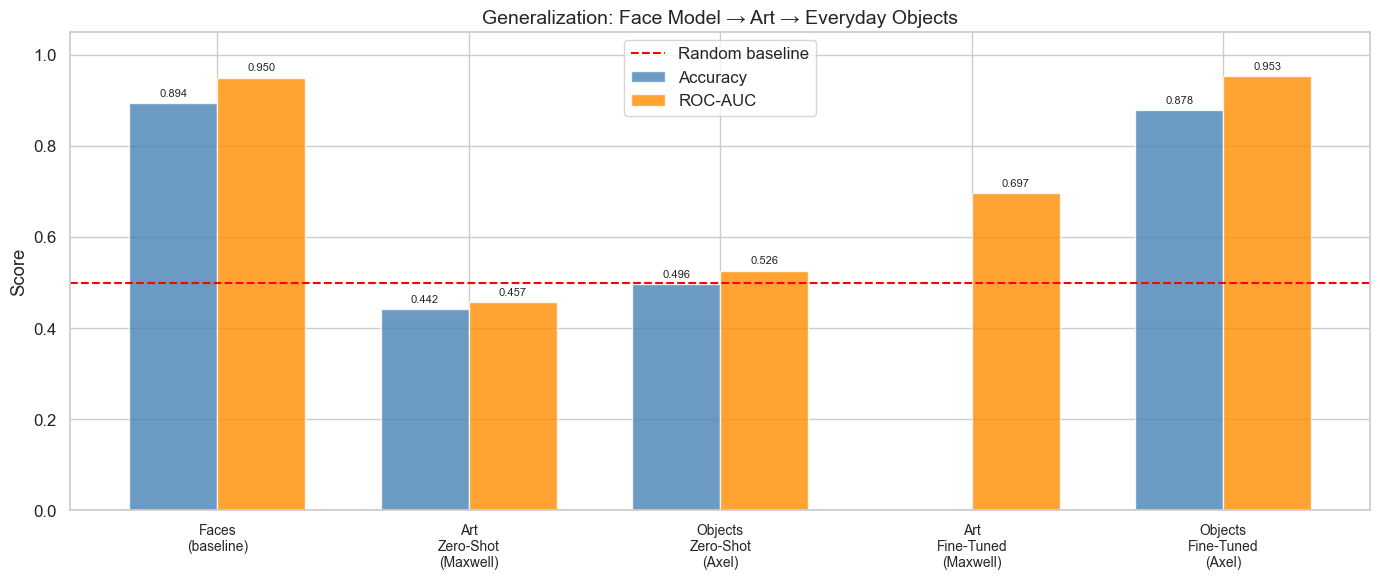

In [20]:
# Maxwell's results from deepfake_art_evaluation.ipynb
ART_ZS_ACC, ART_ZS_AUC = 0.4419, 0.4568
ART_FT_AUC = 0.6965

print('=' * 68)
print(f'  {"Model":<38} {"Accuracy":>10} {"ROC-AUC":>10}')
print('=' * 68)
rows = [
    ('Face model on Faces (training domain)',       0.8936,     '~0.95'),
    ('Face model → Art     (Maxwell, zero-shot)',   ART_ZS_ACC, ART_ZS_AUC),
    ('Face model → Objects (ours,   zero-shot)',    zs_acc,     zs_auc),
    ('Fine-tuned → Art     (Maxwell)',              '–',        ART_FT_AUC),
    ('Fine-tuned → Objects (ours)',                 ft_acc,     ft_auc),
]
for name, acc, auc in rows:
    acc_s = f'{acc:.4f}' if isinstance(acc, float) else str(acc)
    auc_s = f'{auc:.4f}' if isinstance(auc, float) else str(auc)
    print(f'  {name:<38} {acc_s:>10} {auc_s:>10}')
print('=' * 68)

# Bar chart comparison
labels = ['Faces\n(baseline)', 'Art\nZero-Shot\n(Maxwell)', 'Objects\nZero-Shot\n(Axel)',
          'Art\nFine-Tuned\n(Maxwell)', 'Objects\nFine-Tuned\n(Axel)']
accs = [0.8936, ART_ZS_ACC, zs_acc, 0, ft_acc]  # 0 = no acc for Maxwell fine-tuned
aucs = [0.95,   ART_ZS_AUC, zs_auc, ART_FT_AUC, ft_auc]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy',   color='steelblue',  alpha=0.8)
b2 = ax.bar(x + w/2, aucs, w, label='ROC-AUC',    color='darkorange', alpha=0.8)
ax.axhline(0.5, color='red', linestyle='--', lw=1.5, label='Random baseline')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Generalization: Face Model → Art → Everyday Objects', fontsize=14)
ax.legend()
for bar in list(b1) + list(b2):
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Summary & Discussion

In [19]:
print('=' * 62)
print('  SUMMARY — CIFAKE Evaluation')
print('=' * 62)
print(f'  Dataset       : CIFAKE (everyday objects, 10 classes)')
print(f'  Images used   : {len(X):,} ({(y==0).sum():,} REAL / {(y==1).sum():,} FAKE)')
print(f'  Image size    : 32×32 upsampled to {TARGET_SIZE}×{TARGET_SIZE}')
print()
print(f'  Zero-Shot Acc : {zs_acc:.4f}  (majority baseline: {baseline_acc:.4f})')
print(f'  Zero-Shot AUC : {zs_auc:.4f}')
print()
print(f'  Fine-Tuned Acc: {ft_acc:.4f}')
print(f'  Fine-Tuned AUC: {ft_auc:.4f}')
print(f'  Improvement   : Acc {ft_acc-zs_acc:+.4f}  AUC {ft_auc-zs_auc:+.4f}')
print()
print(f'  Art comparison (Maxwell):')
print(f'    Zero-Shot AUC : {ART_ZS_AUC:.4f}')
print(f'    Fine-Tuned AUC: {ART_FT_AUC:.4f}')
print('=' * 62)
print()
if zs_auc < 0.55:
    print('Finding: Zero-shot near random — face artifacts do NOT generalize to objects.')
elif zs_auc < 0.65:
    print('Finding: Weak zero-shot generalization from faces to objects.')
else:
    print('Finding: Meaningful zero-shot generalization from faces to objects.')

if ft_auc > ART_FT_AUC:
    print('Finding: Object fine-tuning outperforms art fine-tuning — EfficientNetB4 features')
    print('         transfer better to natural object images than to artwork.')
else:
    print('Finding: Art fine-tuning outperforms object fine-tuning.')

  SUMMARY — CIFAKE Evaluation
  Dataset       : CIFAKE (everyday objects, 10 classes)
  Images used   : 4,000 (2,000 REAL / 2,000 FAKE)
  Image size    : 32×32 upsampled to 224×224

  Zero-Shot Acc : 0.4963  (majority baseline: 0.5000)
  Zero-Shot AUC : 0.5263

  Fine-Tuned Acc: 0.8783
  Fine-Tuned AUC: 0.9534
  Improvement   : Acc +0.3821  AUC +0.4271

  Art comparison (Maxwell):
    Zero-Shot AUC : 0.4568
    Fine-Tuned AUC: 0.6965

Finding: Zero-shot near random — face artifacts do NOT generalize to objects.
Finding: Object fine-tuning outperforms art fine-tuning — EfficientNetB4 features
         transfer better to natural object images than to artwork.
